# # 🔍 SHAP Explainability — XGBoost Death Score Model
#
# ## Plan
#
# We answer 4 questions with SHAP, going from global to local:
#
# | # | Question | SHAP Tool | What it shows |
# |---|----------|-----------|---------------|
# | 1 | **Which features matter most overall?** | Summary bar plot | Mean absolute SHAP per feature |
# | 2 | **How does each feature push predictions?** | Beeswarm plot | Direction + magnitude per data point |
# | 3 | **How do features interact?** | Dependence plots | Feature value vs SHAP value, colored by interaction |
# | 4 | **Why did the model predict X for this company?** | Waterfall plots | Per-company feature contributions |
#
# Then we build actionable takeaways for the capstone presentation.


In [1]:
#  1  Setup & Load Production Model
#
# We load the exact pipeline saved by final_models_.ipynb so that the SHAP
# analysis reflects the model that is actually in production (tuned XGBoost,
# best params from GridSearchCV: max_depth=4, n_estimators=100, lr=0.05).

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, classification_report

SEED = 42
np.random.seed(SEED)
print(f'SHAP version: {shap.__version__}')

# ── Load production pipeline ─────────────────────────────────────────────────
with open('best_pipeline_bin_death_score.pkl', 'rb') as f:
    pipe = pickle.load(f)

preprocessor = pipe.named_steps['prep']
model        = pipe.named_steps['model']
print(f'Loaded pipeline. Model params: {model.get_params()}')

# ── Load data ────────────────────────────────────────────────────────────────
df = pd.read_csv('../raw_data/features_enriched_with_death_score.csv')
print(f'\nLoaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Target distribution:')
print(df['target_death_score'].value_counts().sort_index())

num_features = [
    'funding_total_usd', 'funding_rounds',
    'seed', 'venture', 'debt_financing', 'angel', 'grant', 'private_equity',
    'round_A', 'round_B', 'round_C', 'round_D', 'round_E',
    'avg_raised_per_round', 'age_first_funding_days',
    'has_multiple_rounds', 'funding_span_days', 'avg_years_between_rounds',
    'time_since_last_funding'
]
cat_features = ['region_group', 'industry_group']

mask = df['target_death_score'].notna()
X = df[mask][num_features + cat_features]
y = df[mask]['target_death_score'].astype(int).values

# Same split as final_models_.ipynb (same SEED + stratify → identical split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Transform using the already-fitted preprocessor from the pipeline
X_test_pp = preprocessor.transform(X_test)

# Feature names after OHE
ohe_names    = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_features).tolist()
feature_names = num_features + ohe_names
print(f'\nTotal features after preprocessing: {len(feature_names)}')

# ── Sanity-check on test set ─────────────────────────────────────────────────
y_pred  = model.predict(X_test_pp)
y_proba = model.predict_proba(X_test_pp)[:, 1]
print(f'\nTest AUC:  {roc_auc_score(y_test, y_proba):.4f}')
print(f'Test F1m:  {f1_score(y_test, y_pred, average="macro"):.4f}')
print(f'\n{classification_report(y_test, y_pred, target_names=["closed", "survived"])}')

SHAP version: 0.49.1
Loaded pipeline. Model params: {'objective': 'binary:logistic', 'use_label_encoder': False, 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': 'logloss', 'feature_types': None, 'gamma': None, 'gpu_id': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.05, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 4, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'n_estimators': 100, 'n_jobs': None, 'num_parallel_tree': None, 'predictor': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.8, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}

Loaded: 43,212 rows x 41 c

In [2]:
#  2 Compute SHAP Values

#
explainer = shap.TreeExplainer(model)

# Compute on test set
shap_values = explainer.shap_values(X_test_pp)

# Wrap in a DataFrame for readable plots
X_test_display = pd.DataFrame(X_test_pp, columns=feature_names)

print(f'SHAP values shape: {shap_values.shape}')
print(f'Expected value (base rate log-odds): {explainer.expected_value:.4f}')

SHAP values shape: (8643, 39)
Expected value (base rate log-odds): -0.1012


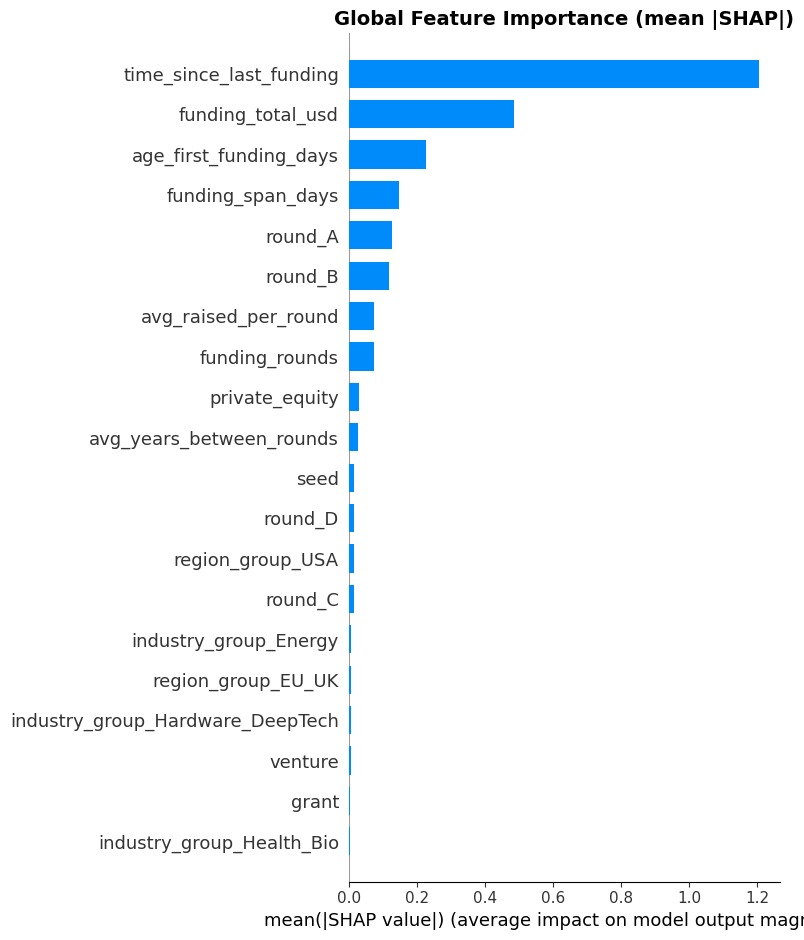

In [3]:
#  3  Global Feature Importance — Bar Plot

# Question: Which features matter most overall?

# The bar plot shows mean |SHAP| per feature — the average magnitude of each
# feature's impact on predictions, regardless of direction.

#
shap.summary_plot(shap_values, X_test_display, plot_type='bar', show=False,
                  max_display=20)
plt.title('Global Feature Importance (mean |SHAP|)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


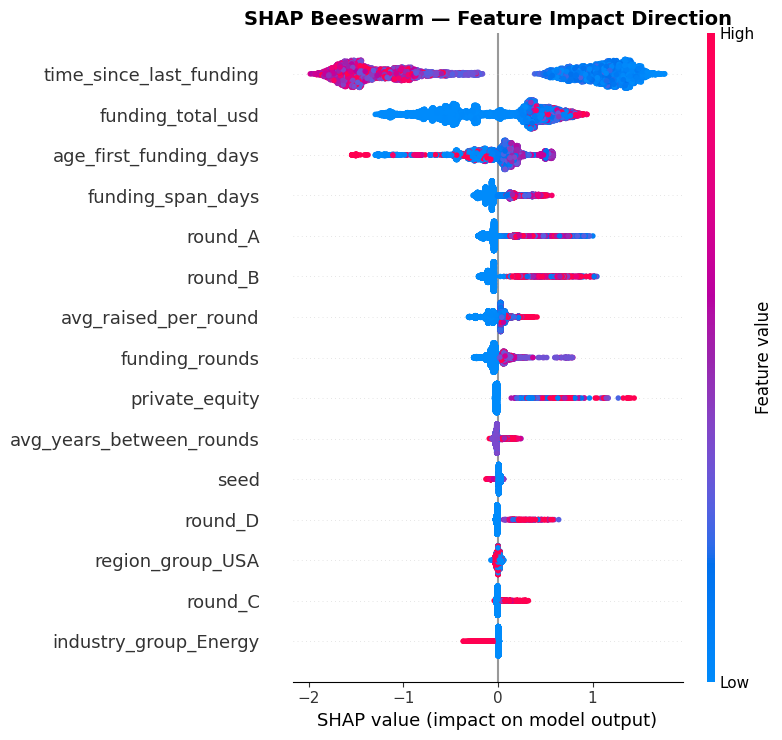

In [4]:
# 4  Beeswarm Plot — Direction + Magnitude

# Question: How does each feature push predictions?

# Each dot is one company. X-axis = SHAP value (positive = pushes toward survived,
# negative = pushes toward closed). Color = feature value (red = high, blue = low).

#
shap.summary_plot(shap_values, X_test_display, show=False, max_display=15)
plt.title('SHAP Beeswarm — Feature Impact Direction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

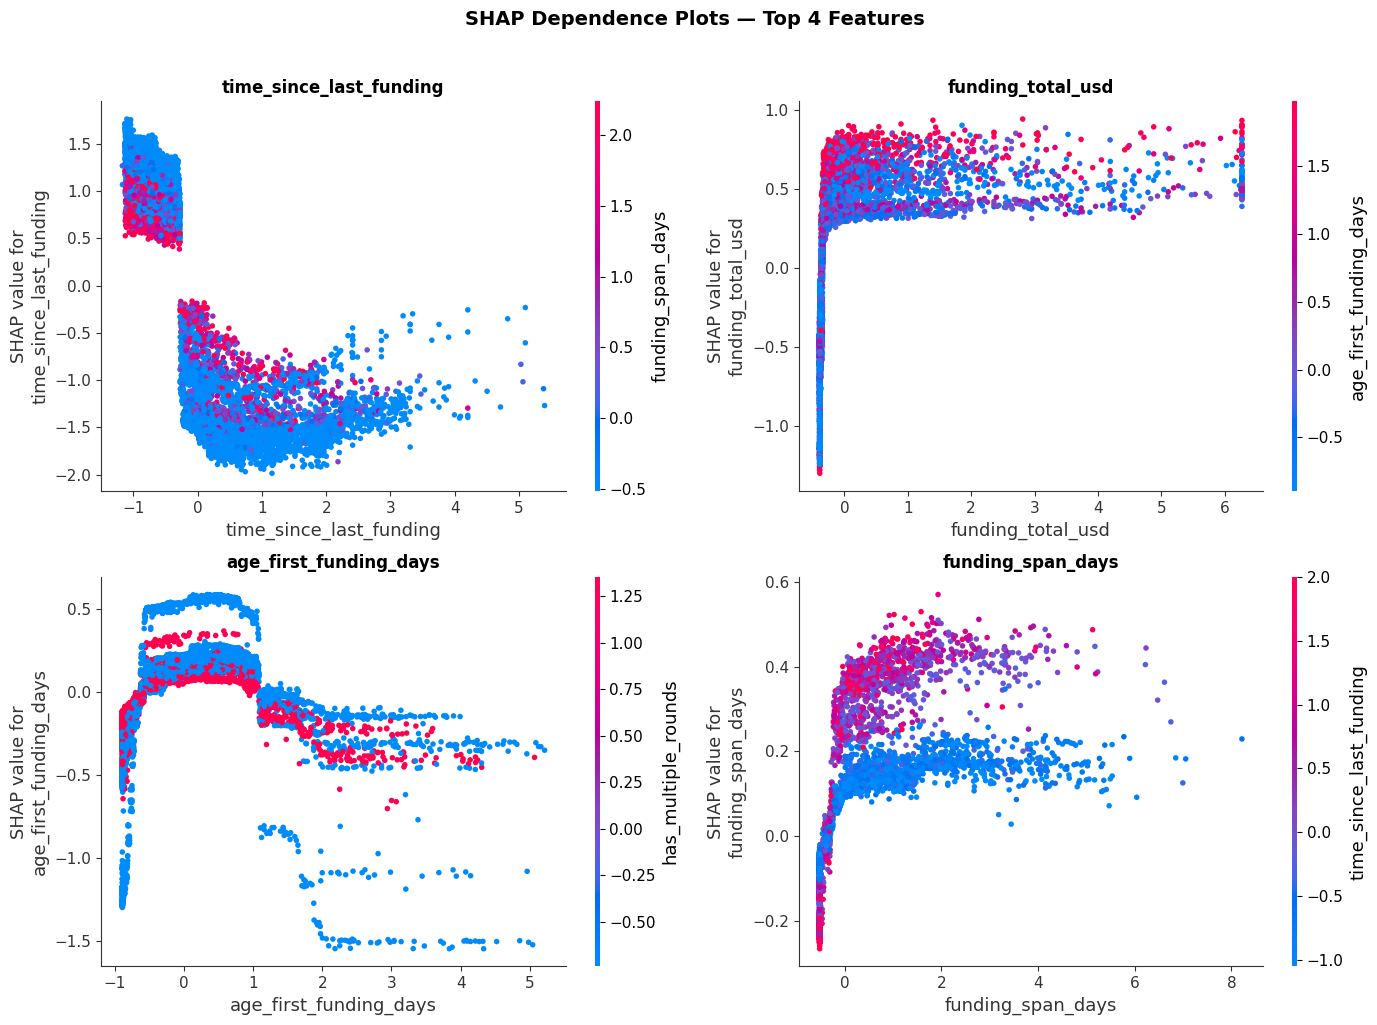

In [5]:
# 5  Dependence Plots — Feature Interactions

# Question: How do specific features interact?

# Shows the relationship between a feature's value and its SHAP impact.
# SHAP auto-selects the strongest interaction feature for coloring.


# Top 4 most important features
top_features_idx = np.argsort(np.abs(shap_values).mean(axis=0))[::-1][:4]
top_feature_names = [feature_names[i] for i in top_features_idx]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, fname in zip(axes.flatten(), top_feature_names):
    idx = feature_names.index(fname)
    shap.dependence_plot(idx, shap_values, X_test_display,
                         feature_names=feature_names, ax=ax, show=False)
    ax.set_title(f'{fname}', fontweight='bold')

plt.suptitle('SHAP Dependence Plots — Top 4 Features', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


  High confidence SURVIVED
  Predicted: survived (93.5%)
  Actual:    survived


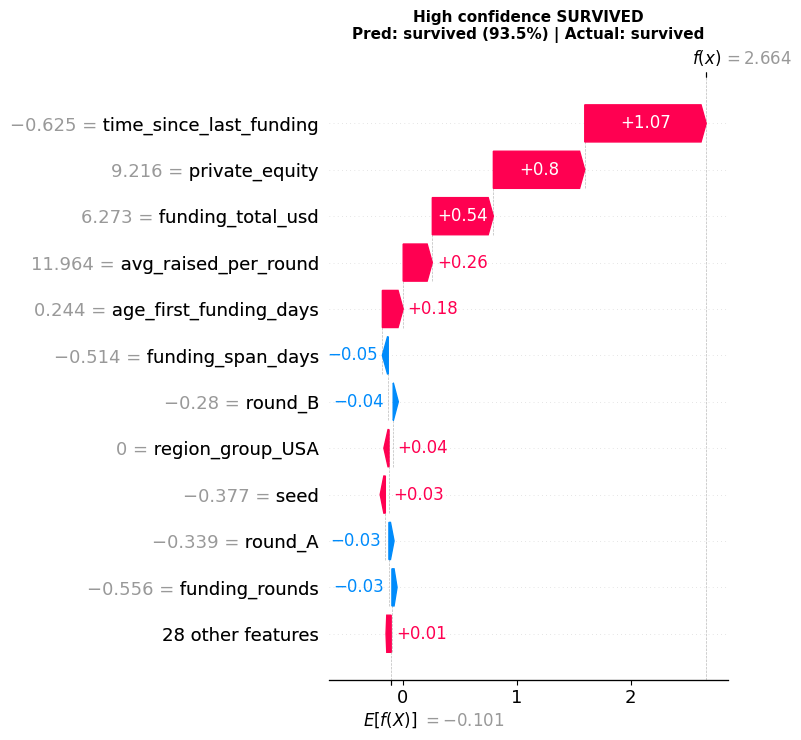


  High confidence CLOSED
  Predicted: closed (96.0%)
  Actual:    closed


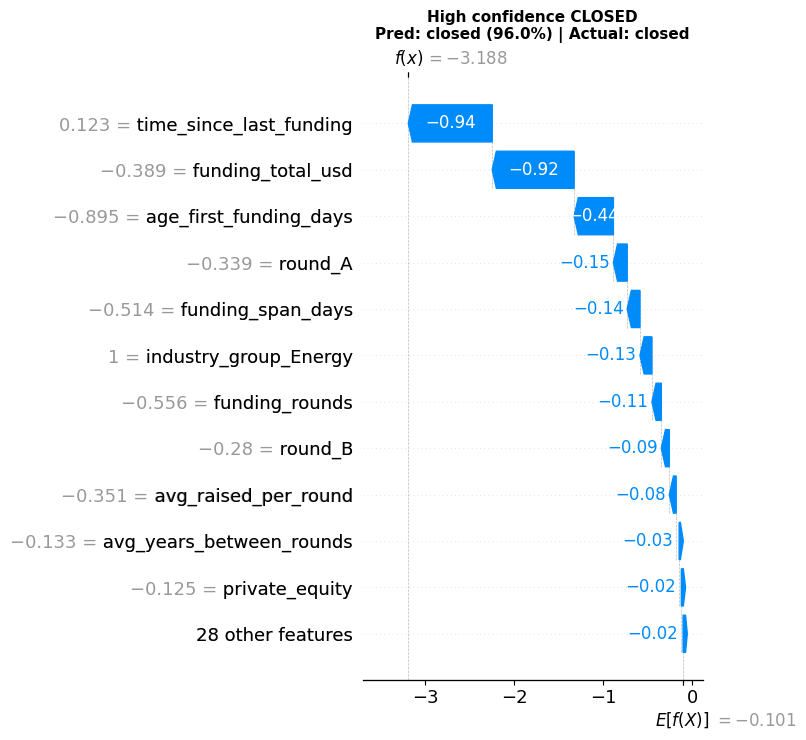


  BORDERLINE case
  Predicted: closed (50.0%)
  Actual:    closed


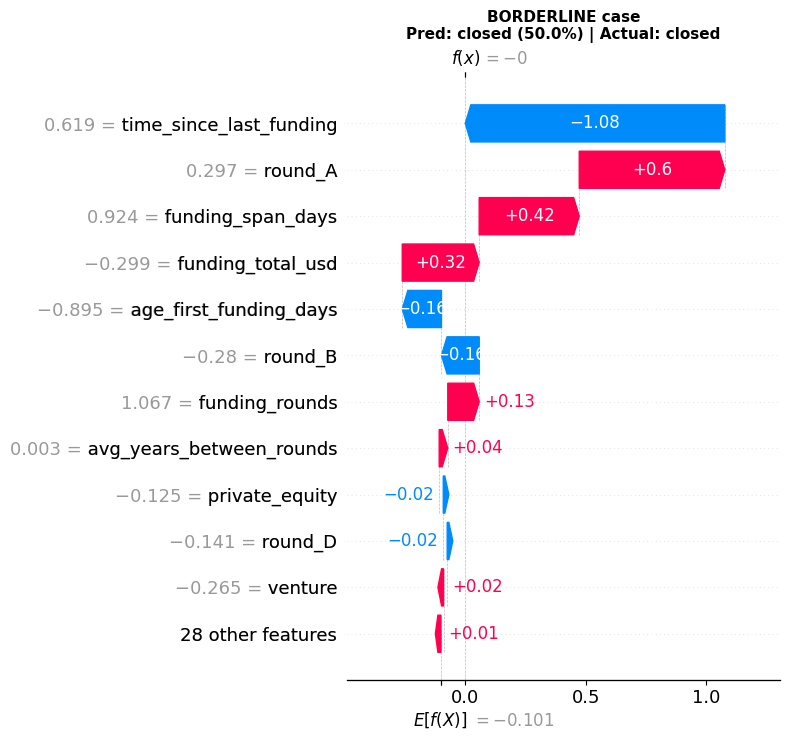

In [6]:
#  6 Individual Predictions — Waterfall Plots

# Question: Why did the model predict X for this specific company?

# We pick example companies from the test set:
# - A company predicted to survive with high confidence
# - A company predicted to die with high confidence
# - A borderline case

# Find interesting examples — CORRECT predictions only
proba_test = model.predict_proba(X_test_pp)[:, 1]
pred_labels = (proba_test > 0.5).astype(int)
correct = pred_labels == y_test

# High confidence survived (correct)
survived_correct = np.where(correct & (y_test == 1))[0]
idx_survived = survived_correct[np.argmax(proba_test[survived_correct])]

# High confidence closed (correct)
closed_correct = np.where(correct & (y_test == 0))[0]
idx_closed = closed_correct[np.argmin(proba_test[closed_correct])]

# Borderline (closest to 0.5)
idx_borderline = np.argmin(np.abs(proba_test - 0.5))

examples = {
    'High confidence SURVIVED': idx_survived,
    'High confidence CLOSED': idx_closed,
    'BORDERLINE case': idx_borderline,
}

for title, idx in examples.items():
    prob = proba_test[idx]
    actual = y_test[idx]
    actual_label = 'survived' if actual == 1 else 'closed'
    pred_label = 'survived' if prob > 0.5 else 'closed'
    confidence = prob if prob > 0.5 else 1 - prob

    print(f'\n{"="*60}')
    print(f'  {title}')
    print(f'  Predicted: {pred_label} ({confidence:.1%})')
    print(f'  Actual:    {actual_label}')
    print(f'{"="*60}')

    explanation = shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_test_pp[idx],
        feature_names=feature_names,
    )

    shap.waterfall_plot(explanation, max_display=12, show=False)
    plt.title(f'{title}\nPred: {pred_label} ({confidence:.1%}) | Actual: {actual_label}',
              fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

Misclassified: 1521 / 8643 (17.6%)
  False positives (predicted survived, was closed): 1028
  False negatives (predicted closed, was survived): 493

Worst false positive: predicted survived at 94.5%, actually closed


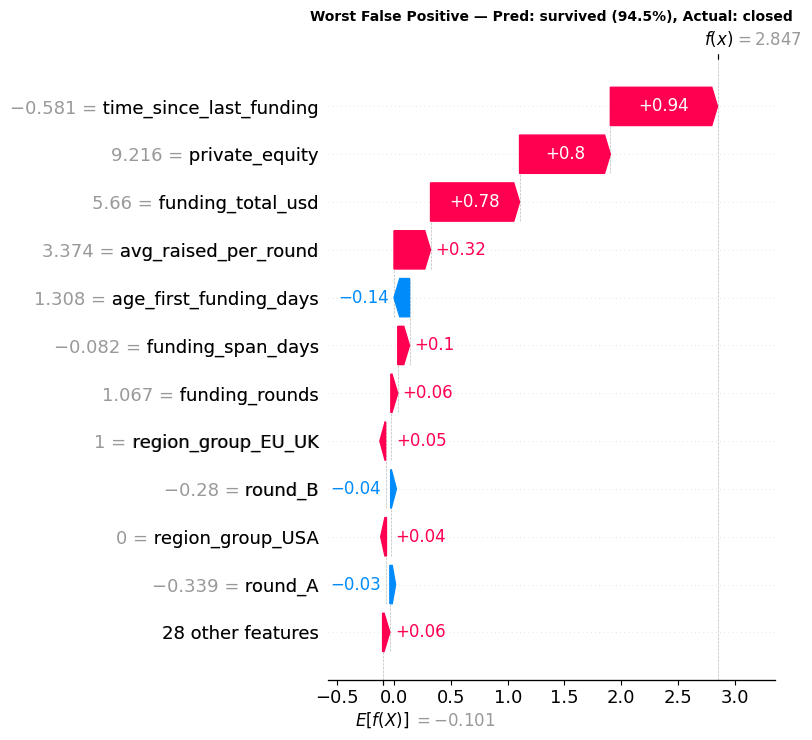


Worst false negative: predicted closed at 4.9%, actually survived


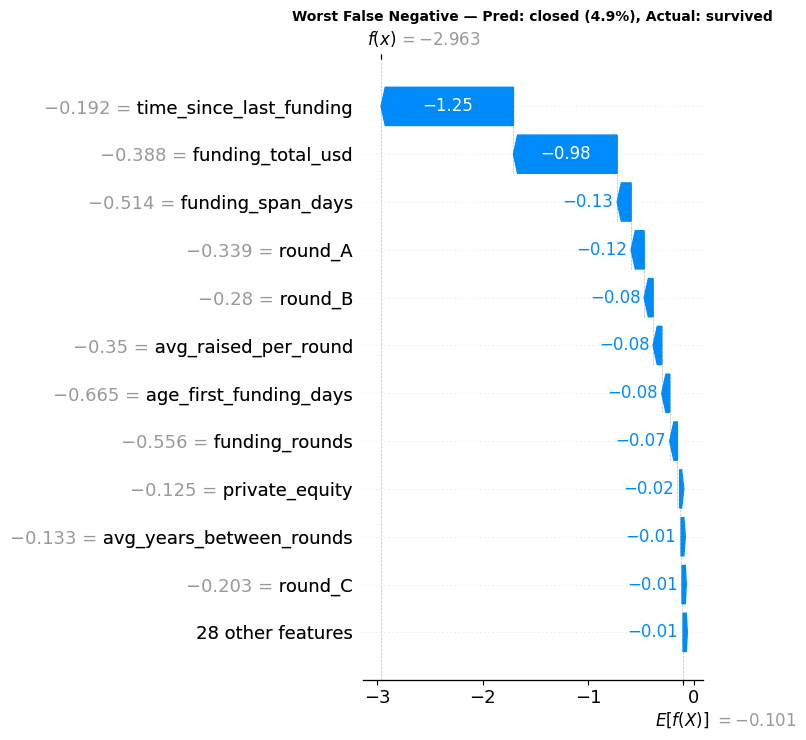

In [7]:
#  7 Misclassification Analysis

# Question: Where does the model fail, and what does SHAP say about those cases?

# Find misclassified examples
pred_labels = (proba_test > 0.5).astype(int)
wrong = np.where(pred_labels != y_test)[0]
print(f'Misclassified: {len(wrong)} / {len(y_test)} ({len(wrong)/len(y_test)*100:.1f}%)')

# False positives: predicted survived, actually closed
fp = wrong[y_test[wrong] == 0]
# False negatives: predicted closed, actually survived
fn = wrong[y_test[wrong] == 1]
print(f'  False positives (predicted survived, was closed): {len(fp)}')
print(f'  False negatives (predicted closed, was survived): {len(fn)}')

# Show SHAP for a confident false positive and false negative
if len(fp) > 0:
    # Most confident wrong survival prediction
    fp_probs = proba_test[fp]
    fp_worst = fp[np.argmax(fp_probs)]
    print(f'\nWorst false positive: predicted survived at {proba_test[fp_worst]:.1%}, actually closed')
    explanation = shap.Explanation(
        values=shap_values[fp_worst],
        base_values=explainer.expected_value,
        data=X_test_pp[fp_worst],
        feature_names=feature_names,
    )
    shap.waterfall_plot(explanation, max_display=12, show=False)
    plt.title(f'Worst False Positive — Pred: survived ({proba_test[fp_worst]:.1%}), Actual: closed',
              fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.show()

if len(fn) > 0:
    fn_probs = proba_test[fn]
    fn_worst = fn[np.argmin(fn_probs)]
    print(f'\nWorst false negative: predicted closed at {proba_test[fn_worst]:.1%}, actually survived')
    explanation = shap.Explanation(
        values=shap_values[fn_worst],
        base_values=explainer.expected_value,
        data=X_test_pp[fn_worst],
        feature_names=feature_names,
    )
    shap.waterfall_plot(explanation, max_display=12, show=False)
    plt.title(f'Worst False Negative — Pred: closed ({proba_test[fn_worst]:.1%}), Actual: survived',
              fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.show()

Top 10 features by importance:
                 feature  mean_abs_shap  mean_shap      direction
 time_since_last_funding       1.206320  -0.048739 favors closure
       funding_total_usd       0.485983  -0.031634 favors closure
  age_first_funding_days       0.228415  -0.035509 favors closure
       funding_span_days       0.146712  -0.002368 favors closure
                 round_A       0.126057  -0.007184 favors closure
                 round_B       0.119636  -0.027466 favors closure
    avg_raised_per_round       0.075743  -0.006907 favors closure
          funding_rounds       0.074348  -0.005588 favors closure
          private_equity       0.031226  -0.001338 favors closure
avg_years_between_rounds       0.026490  -0.002096 favors closure


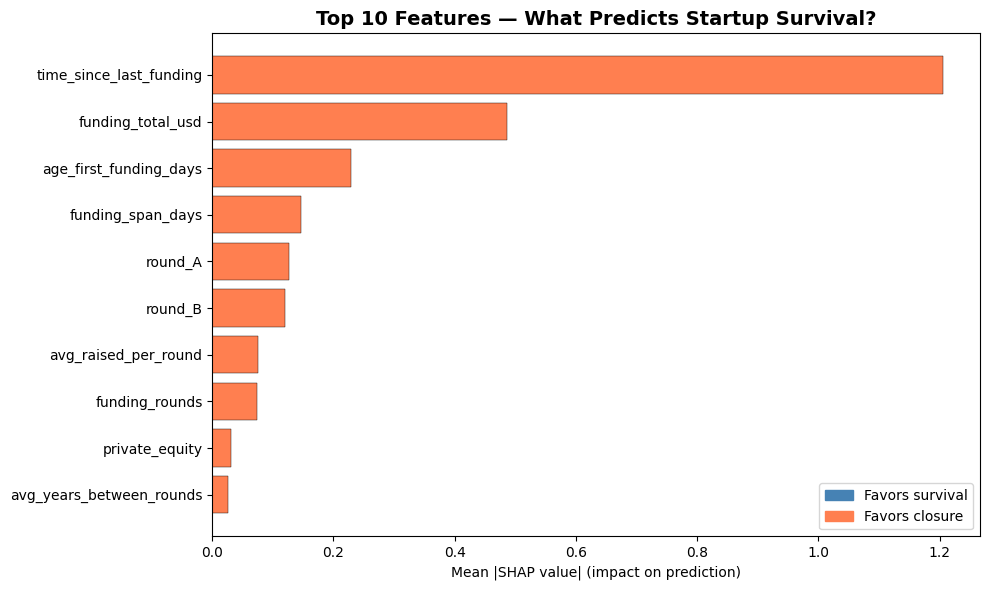

In [8]:
#  8 Capstone-Ready Summary Table

#
# Build a clean summary of feature impacts
mean_abs_shap = np.abs(shap_values).mean(axis=0)
mean_shap = shap_values.mean(axis=0)

summary = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': mean_abs_shap,
    'mean_shap': mean_shap,
    'direction': ['favors survival' if s > 0 else 'favors closure' for s in mean_shap],
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

print('Top 10 features by importance:')
print(summary.head(10).to_string(index=False))

#
# Clean bar chart for the presentation
top10 = summary.head(10).sort_values('mean_abs_shap')
colors = ['steelblue' if d == 'favors survival' else 'coral' for d in top10['direction']]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top10['feature'], top10['mean_abs_shap'], color=colors, edgecolor='black', linewidth=0.3)
ax.set_xlabel('Mean |SHAP value| (impact on prediction)')
ax.set_title('Top 10 Features — What Predicts Startup Survival?', fontsize=14, fontweight='bold')

import matplotlib.patches as mpatches
ax.legend(handles=[
    mpatches.Patch(color='steelblue', label='Favors survival'),
    mpatches.Patch(color='coral', label='Favors closure'),
], loc='lower right')

plt.tight_layout()
plt.show()

In [9]:
#  9  Permutation Importance × SHAP — Cross-validation
#
# Cross-validate the permutation importance rankings (from final_models_.ipynb)
# against mean |SHAP| values. Features that score low on BOTH metrics are the
# only safe candidates for removal. Features that diverge between the two methods
# need domain-knowledge review before any decision is made.

# ── Permutation importance results from final_models_.ipynb (baseline XGBoost) ──
perm_data = {
    'time_since_last_funding':          0.22783,
    'funding_total_usd':                0.05520,
    'age_first_funding_days':           0.05015,
    'round_B':                          0.01124,
    'round_A':                          0.01026,
    'funding_span_days':                0.00692,
    'funding_rounds':                   0.00481,
    'avg_raised_per_round':             0.00416,
    'round_C':                          0.00296,
    'private_equity':                   0.00220,
    'venture':                          0.00171,
    'round_D':                          0.00168,
    'seed':                             0.00163,
    'industry_group_Health_Bio':        0.00107,
    'avg_years_between_rounds':         0.00095,
    'industry_group_Consumer_Internet': 0.00070,
    'grant':                            0.00067,
    'industry_group_Software_Data':     0.00065,
    'debt_financing':                   0.00059,
    'region_group_Asia':                0.00048,
    'region_group_USA':                 0.00041,
    'region_group_EU_UK':               0.00032,
    'region_group_Rest_World':          0.00023,
    'angel':                            0.00022,
    'industry_group_Unknown':           0.00020,
    'industry_group_Energy':            0.00018,
    'region_group_Canada':              0.00016,
    'industry_group_Other':             0.00006,
    'industry_group_Education':         0.00001,
    'has_multiple_rounds':              0.00000,
    'round_E':                          0.00000,
    'region_group_Australia':           0.00000,
    'industry_group_Services':         -0.00000,
    'industry_group_Real_World':       -0.00001,
    'industry_group_Ecommerce':        -0.00002,
    'industry_group_FinTech':          -0.00005,
    'region_group_Unknown':            -0.00006,
    'industry_group_Hardware_DeepTech':-0.00008,
    'region_group_Rest_Americas':      -0.00017,
}

# ── SHAP summary (computed above) ────────────────────────────────────────────
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({'feature': feature_names, 'mean_abs_shap': mean_abs_shap})

# ── Merge ─────────────────────────────────────────────────────────────────────
perm_df = pd.DataFrame(list(perm_data.items()), columns=['feature', 'perm_importance'])
compare = shap_df.merge(perm_df, on='feature', how='left')

# Rank each method (1 = most important)
compare['shap_rank'] = compare['mean_abs_shap'].rank(ascending=False).astype(int)
compare['perm_rank'] = compare['perm_importance'].rank(ascending=False).astype(int)
compare['rank_delta'] = (compare['shap_rank'] - compare['perm_rank']).abs()

compare = compare.sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

print('SHAP vs Permutation Importance — Full Cross-validation\n')
print(f"  {'Feature':<40} {'SHAP |mean|':>12} {'Perm imp':>10} {'SHAP rank':>10} {'Perm rank':>10} {'|Δrank|':>8}")
print(f"  {'-'*92}")
for _, row in compare.iterrows():
    flag = '  ** DIVERGES **' if row['rank_delta'] > 8 else ''
    print(f"  {row['feature']:<40} {row['mean_abs_shap']:>12.5f} {row['perm_importance']:>10.5f} "
          f"{row['shap_rank']:>10} {row['perm_rank']:>10} {row['rank_delta']:>8}{flag}")

# ── Flag candidates ───────────────────────────────────────────────────────────
SHAP_THRESH = 0.005   # mean |SHAP| < 0.005 → low SHAP signal
PERM_THRESH = 0.0005  # perm importance < 0.0005 → low perm signal

low_both = compare[
    (compare['mean_abs_shap'] < SHAP_THRESH) &
    (compare['perm_importance'] < PERM_THRESH)
]
low_shap_only = compare[
    (compare['mean_abs_shap'] < SHAP_THRESH) &
    (compare['perm_importance'] >= PERM_THRESH)
]
low_perm_only = compare[
    (compare['mean_abs_shap'] >= SHAP_THRESH) &
    (compare['perm_importance'] < PERM_THRESH)
]

print(f'\n{"="*70}')
print('VERDICT')
print(f'{"="*70}')
print(f'\n[SAFE TO DROP — low on BOTH metrics] ({len(low_both)} features):')
for _, r in low_both.iterrows():
    print(f'  • {r["feature"]:<40}  SHAP={r["mean_abs_shap"]:.5f}  perm={r["perm_importance"]:.5f}')

print(f'\n[REVIEW — low SHAP only, perm disagrees] ({len(low_shap_only)} features):')
for _, r in low_shap_only.iterrows():
    print(f'  • {r["feature"]:<40}  SHAP={r["mean_abs_shap"]:.5f}  perm={r["perm_importance"]:.5f}')

print(f'\n[REVIEW — low perm only, SHAP disagrees] ({len(low_perm_only)} features):')
for _, r in low_perm_only.iterrows():
    print(f'  • {r["feature"]:<40}  SHAP={r["mean_abs_shap"]:.5f}  perm={r["perm_importance"]:.5f}')

SHAP vs Permutation Importance — Full Cross-validation

  Feature                                   SHAP |mean|   Perm imp  SHAP rank  Perm rank  |Δrank|
  --------------------------------------------------------------------------------------------
  time_since_last_funding                       1.20632    0.22783          1          1        0
  funding_total_usd                             0.48598    0.05520          2          2        0
  age_first_funding_days                        0.22842    0.05015          3          3        0
  funding_span_days                             0.14671    0.00692          4          6        2
  round_A                                       0.12606    0.01026          5          5        0
  round_B                                       0.11964    0.01124          6          4        2
  avg_raised_per_round                          0.07574    0.00416          7          8        1
  funding_rounds                                0.07435    0.0048

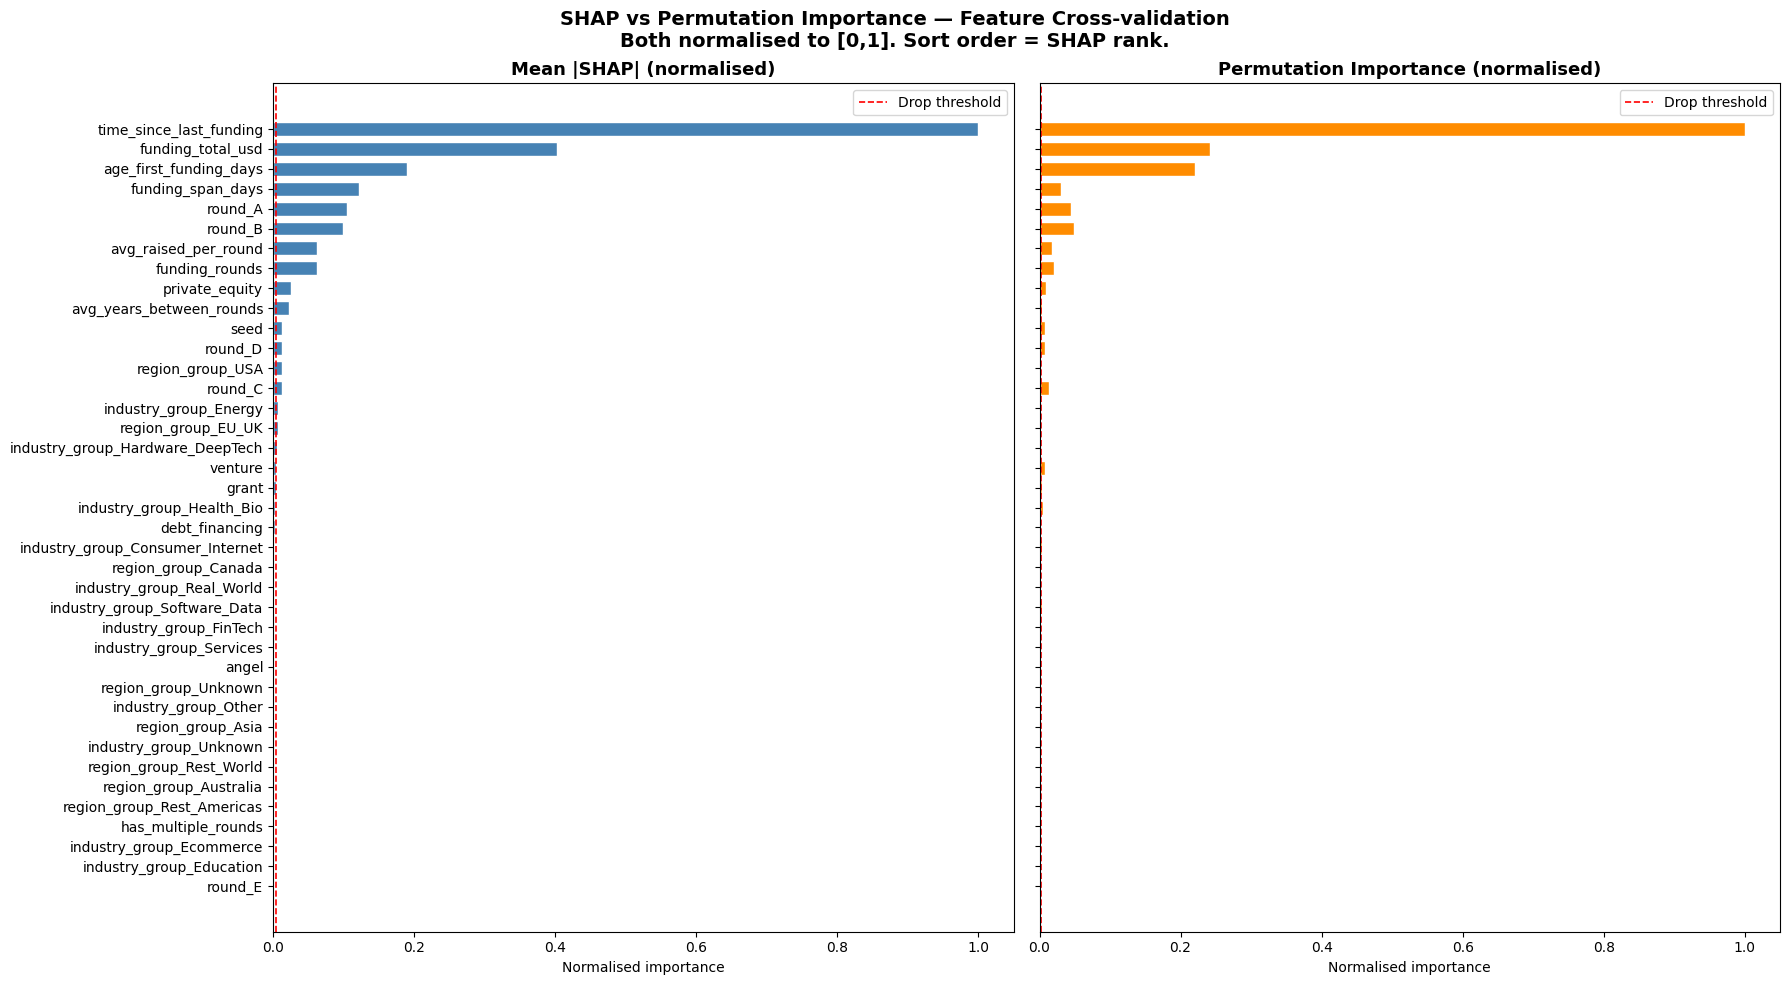


FINAL DROP RECOMMENDATION (agree on both methods)

Numeric features safe to drop: ['angel', 'has_multiple_rounds', 'round_E']

OHE columns consistently low (parent cat may still be useful):
  • region_group_Canada
  • industry_group_Real_World
  • industry_group_FinTech
  • industry_group_Services
  • region_group_Unknown
  • industry_group_Other
  • region_group_Asia
  • industry_group_Unknown
  • industry_group_Education
  • industry_group_Ecommerce
  • region_group_Rest_World
  • region_group_Rest_Americas
  • region_group_Australia


In [10]:
#  10  Permutation × SHAP — Side-by-side Bar Chart
#
# Both metrics are min-max normalised to [0, 1] so they share the same axis.
# Features are sorted by mean SHAP rank. Bars coloured by verdict:
#   green  → agreement (both high or both low)
#   orange → divergence (methods disagree)
#   red    → flagged by perm, awaiting SHAP confirmation

# Normalise to [0, 1]
compare_plot = compare.copy()
compare_plot['shap_norm'] = (compare_plot['mean_abs_shap'] / compare_plot['mean_abs_shap'].max())
compare_plot['perm_norm']  = (compare_plot['perm_importance'].clip(lower=0) /
                               compare_plot['perm_importance'].clip(lower=0).max())

compare_plot = compare_plot.sort_values('shap_norm', ascending=True).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 10), sharey=True)

# --- SHAP ---
axes[0].barh(compare_plot['feature'], compare_plot['shap_norm'],
             color='steelblue', edgecolor='white', height=0.7)
axes[0].axvline(SHAP_THRESH / compare['mean_abs_shap'].max(), color='red',
                linestyle='--', linewidth=1.2, label=f'Drop threshold')
axes[0].set_title('Mean |SHAP| (normalised)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Normalised importance')
axes[0].legend()

# --- Permutation ---
colors_perm = ['#d62728' if v <= 0 else 'darkorange' for v in compare_plot['perm_norm']]
axes[1].barh(compare_plot['feature'], compare_plot['perm_norm'],
             color=colors_perm, edgecolor='white', height=0.7)
axes[1].axvline(PERM_THRESH / compare['perm_importance'].clip(lower=0).max(),
                color='red', linestyle='--', linewidth=1.2, label='Drop threshold')
axes[1].set_title('Permutation Importance (normalised)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Normalised importance')
axes[1].legend()

plt.suptitle('SHAP vs Permutation Importance — Feature Cross-validation\n'
             'Both normalised to [0,1]. Sort order = SHAP rank.',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Final drop recommendation printout ───────────────────────────────────────
print('\n' + '='*60)
print('FINAL DROP RECOMMENDATION (agree on both methods)')
print('='*60)
numeric_drops = [r['feature'] for _, r in low_both.iterrows()
                 if r['feature'] in num_features]
print(f'\nNumeric features safe to drop: {numeric_drops or "none — verify with domain knowledge"}')
cat_drops = [r['feature'] for _, r in low_both.iterrows()
             if r['feature'] not in num_features]
if cat_drops:
    print(f'\nOHE columns consistently low (parent cat may still be useful):')
    for f in cat_drops:
        print(f'  • {f}')